# Week 2, Day 2 — Does Memory Help?

**Before this notebook:** read the illustrated guide to LSTMs and GRUs from the
reading list. It covers both architectures in one article — useful, since
`GRURegressor` exists in this codebase alongside `LSTMRegressor`, and you're
welcome to try both today.

**Yesterday's cliffhanger:** an MLP, looking at a sine wave one point at a
time, converged to nothing more than "predict no change." Not because it
failed to learn — because a single point can't tell you which direction a wave
is currently moving, and no amount of training fixes a question the input
can't answer.

**Today's question:** does seeing a short window of *recent* points fix that?
And if it fixes the toy wave — does the fix actually transfer to a real,
noisy, non-periodic stock?

In [2]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


## 1. Recap — where yesterday left off

Same wave, same MLP, same single-point input. Quick recap run, so both numbers
are on the same page in front of you before we change anything.

In [3]:
torch.manual_seed(0); np.random.seed(0)

t = np.linspace(0, 200*np.pi, 4000)
series = np.sin(t) + 0.03*np.random.randn(len(t))

X = series[:-1].reshape(-1, 1).astype('float32')
y = series[1:].astype('float32')
split = int(len(X) * 0.7)
Xtr, ytr = torch.tensor(X[:split]), torch.tensor(y[:split])
Xte, yte = torch.tensor(X[split:]), torch.tensor(y[split:])

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

mlp = MLP()
opt = torch.optim.Adam(mlp.parameters(), lr=0.01)
for epoch in range(300):
    opt.zero_grad()
    loss = nn.functional.mse_loss(mlp(Xtr), ytr)
    loss.backward(); opt.step()
mlp_test_loss = nn.functional.mse_loss(mlp(Xte), yte).item()
persistence_loss = nn.functional.mse_loss(Xte.squeeze(-1), yte).item()

print(f'yesterday -- MLP test loss:          {mlp_test_loss:.5f}')
print(f'yesterday -- "no change" baseline:   {persistence_loss:.5f}')
print('(these should be nearly identical -- that was the whole point)')

yesterday -- MLP test loss:          0.01402
yesterday -- "no change" baseline:   0.01410
(these should be nearly identical -- that was the whole point)


## 2. Same wave, a window instead of a point

Now give the model the last 5 days instead of just today, and swap the
architecture for an LSTM. **Everything else about the problem is identical** —
same wave, same noise, same train/test split, same number of training epochs.
The only thing that changes is what the model is allowed to see.

In [4]:
seq_len = 5
Xs, ys = [], []
for i in range(seq_len, len(series) - 1):
    Xs.append(series[i-seq_len:i])
    ys.append(series[i])
Xs = np.array(Xs, dtype='float32').reshape(-1, seq_len, 1)
ys = np.array(ys, dtype='float32')

split2 = int(len(Xs) * 0.7)
Xtr2, ytr2 = torch.tensor(Xs[:split2]), torch.tensor(ys[:split2])
Xte2, yte2 = torch.tensor(Xs[split2:]), torch.tensor(ys[split2:])

class LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True)
        self.head = nn.Linear(32, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)

torch.manual_seed(0)
lstm = LSTM()
opt2 = torch.optim.Adam(lstm.parameters(), lr=0.01)
train_hist, test_hist = [], []
for epoch in range(300):
    opt2.zero_grad()
    loss = nn.functional.mse_loss(lstm(Xtr2), ytr2)
    loss.backward(); opt2.step()
    train_hist.append(loss.item())
    test_hist.append(nn.functional.mse_loss(lstm(Xte2), yte2).item())

print(f'LSTM (5-step window) test loss: {test_hist[-1]:.5f}')
print(f'MLP  (1-point) test loss:       {mlp_test_loss:.5f}')
print(f'error reduction: {mlp_test_loss/test_hist[-1]:.1f}x smaller')

LSTM (5-step window) test loss: 0.00186
MLP  (1-point) test loss:       0.01402
error reduction: 7.5x smaller


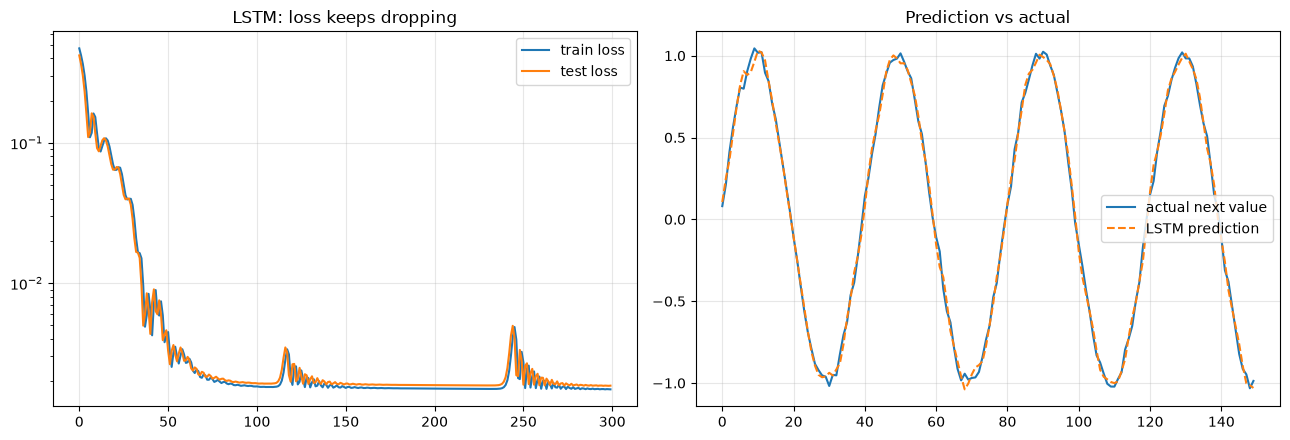

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(train_hist, label='train loss')
axes[0].plot(test_hist, label='test loss')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[0].set_title('LSTM: loss keeps dropping')

with torch.no_grad():
    pred_test2 = lstm(Xte2).numpy()
show_n = 150
axes[1].plot(ys[split2:split2+show_n], label='actual next value', linewidth=1.5)
axes[1].plot(pred_test2[:show_n], label='LSTM prediction', linewidth=1.5, linestyle='--')
axes[1].legend(); axes[1].grid(alpha=.3); axes[1].set_title('Prediction vs actual')
plt.tight_layout(); plt.show()

**Compare this plot to yesterday's.** The dashed line isn't lagging one step
behind anymore — it's tracking the actual shape of the curve, peaks and
troughs included. Seeing five consecutive points gave the model exactly what a
single point couldn't: direction. That's the whole mechanism, made visible.

**A note on why this worked, precisely:** an LSTM's hidden state updates once
per timestep it processes. Over 5 steps, that hidden state can encode
something like "the last few values have been rising" — information a single
point structurally cannot contain. This isn't LSTM-specific magic; any model
architecture that consumes a window instead of a point would get the same
benefit. LSTM (and GRU) are just well-suited *ways* to consume that window.